<a href="https://colab.research.google.com/github/sujitx-vs/PGCP-AI_PML/blob/main/Day10_PML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/SNP.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
df.isna().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

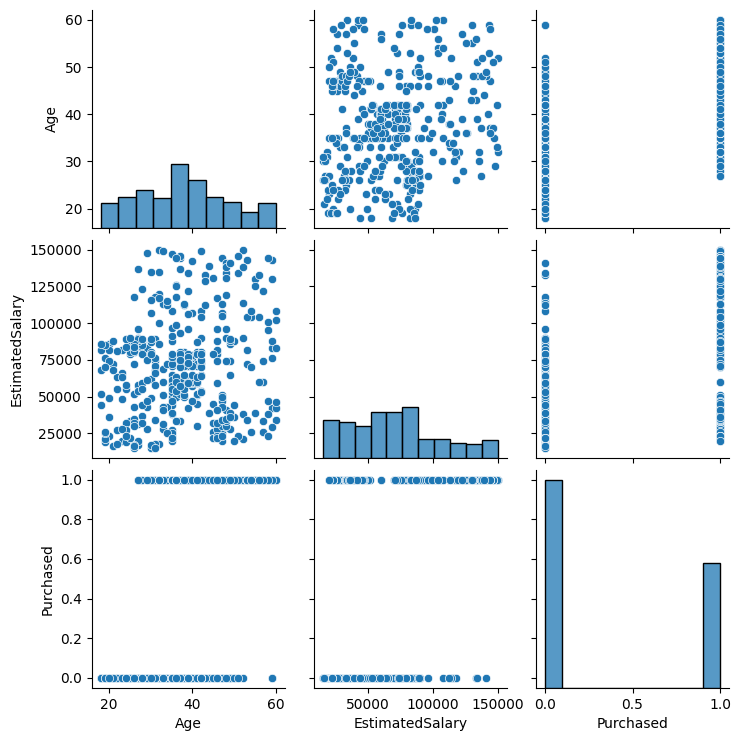

In [ ]:
sns.pairplot(df)

<Axes: xlabel='Age', ylabel='Count'>

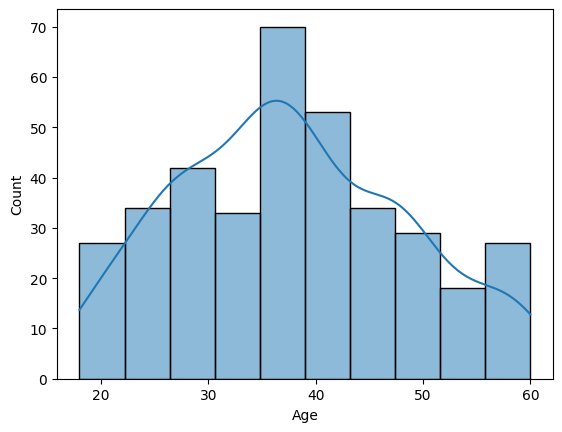

In [ ]:
sns.histplot(df['Age'],kde=True)

/tmp/ipykernel_21015/2218174724.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='EstimatedSalary', ylabel='Density'>

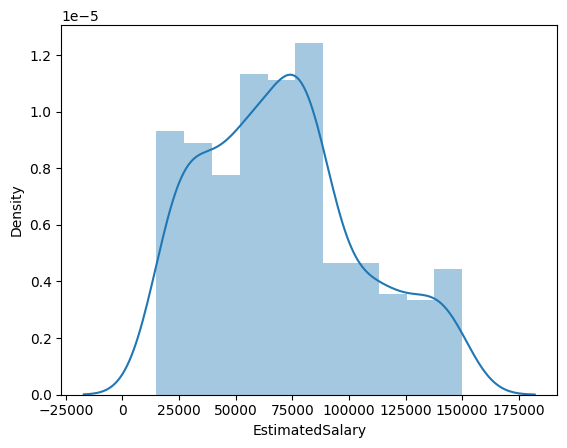

In [ ]:
sns.distplot(df['EstimatedSalary'])

<Axes: >

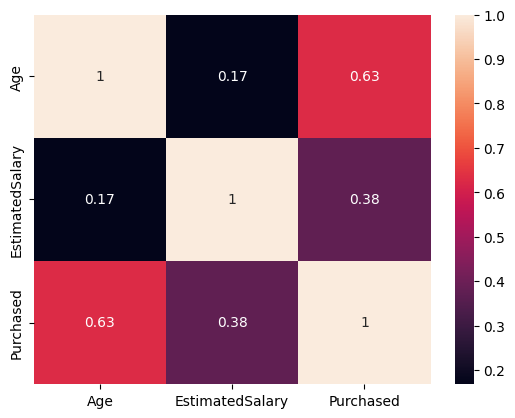

In [ ]:
sns.heatmap(df.corr(),annot=True)

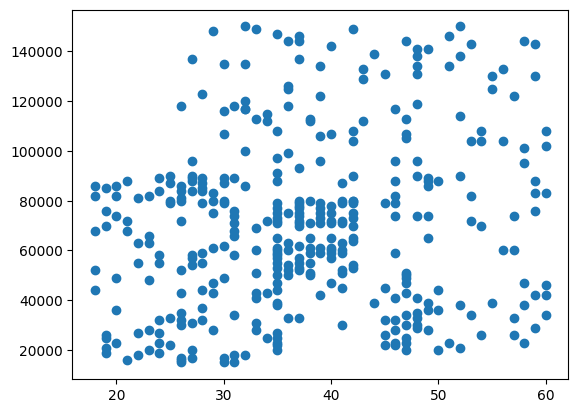

In [ ]:
plt.scatter(df['Age'],df['EstimatedSalary'])

In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)



In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.svm import SVC

In [ ]:
model = SVC(kernel='linear',random_state=0)

In [ ]:
model.fit(X_train,Y_train)

SVC(kernel='linear', random_state=0)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(Y_test,y_pred)

0.8243243243243243

In [ ]:
pred1 = model.predict(sc.transform([[30,87000]]))
pred1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([0])

In [ ]:
def plot_decision_boundary(X_set, y_set, title):
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    plt.figure()
    plt.contourf(
        X1, X2,
        model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.3
    )

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )

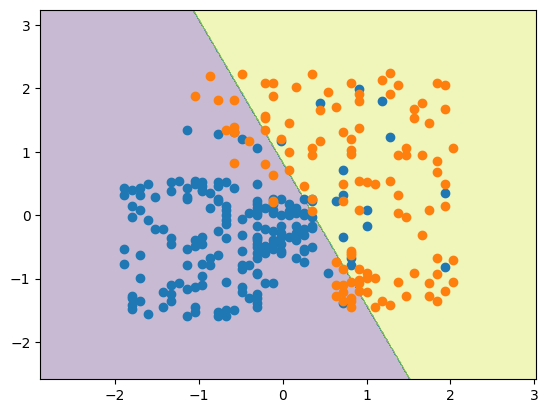

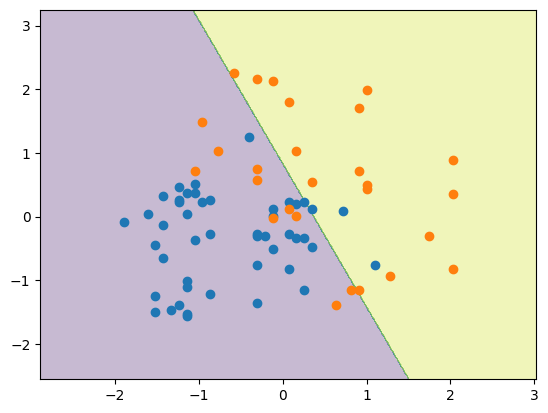

In [ ]:
plot_decision_boundary(X_train,Y_train,'Train Set')
plot_decision_boundary(X_test,Y_test,"")
plt.show()

In [ ]:
df["AgeXSalary"]= df['Age']*df['EstimatedSalary']

In [ ]:
df

,Age,EstimatedSalary,Purchased,AgeXSalary
0,19,19000,0,361000
1,35,20000,0,700000
2,26,43000,0,1118000
3,27,57000,0,1539000
4,19,76000,0,1444000
...,...,...,...,...
395,46,41000,1,1886000
396,51,23000,1,1173000
397,50,20000,1,1000000
398,36,33000,0,1188000


In [ ]:
X = df.drop('Purchased',axis=1)
Y = df["Purchased"]

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
model = SVC(kernel='rbf',random_state=0)

In [ ]:
model.fit(X_train,Y_train)


SVC(random_state=0)

In [ ]:
Y_pred = model.predict(X_test)

In [ ]:
accuracy_score(Y_test,Y_pred)

0.8918918918918919

In [ ]:
def plot_decision_boundary(X_set, y_set, title):
    X_set = np.array(X_set)
    y_set = np.array(y_set).ravel()

    X1, X2 = np.meshgrid(
        np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
        np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
    )

    # FIX third feature as mean
    X3_fixed = np.mean(X_set[:, 2])

    grid = np.c_[X1.ravel(), X2.ravel(), np.full(X1.ravel().shape, X3_fixed)]

    plt.figure()
    plt.contourf(
        X1, X2,
        model.predict(grid).reshape(X1.shape),
        alpha=0.3
    )

    for j in np.unique(y_set):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            label=j
        )

    plt.title(title)
    plt.legend()
    plt.show()

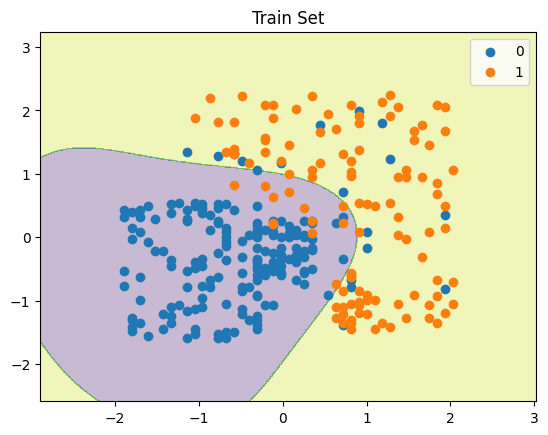

In [ ]:
plot_decision_boundary(X_train,Y_train,'Train Set')

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_decision_boundary(X_set, y_set, model):
    X_set = np.array(X_set)
    y_set = np.array(y_set).ravel()

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot actual data points
    for j in np.unique(y_set):
        ax.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            X_set[y_set == j, 2],
            label=f"Class {j}"
        )

    # Create grid
    x_range = np.linspace(X_set[:,0].min(), X_set[:,0].max(), 20)
    y_range = np.linspace(X_set[:,1].min(), X_set[:,1].max(), 20)
    z_range = np.linspace(X_set[:,2].min(), X_set[:,2].max(), 20)

    xx, yy, zz = np.meshgrid(x_range, y_range, z_range)

    grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

    # Predict
    preds = model.predict(grid)

    # Plot predicted regions (light)
    ax.scatter(
        grid[:,0], grid[:,1], grid[:,2],
        c=preds,
        alpha=0.05
    )

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    ax.set_title('3D Decision Boundary (Approximation)')
    ax.legend()

    plt.show()

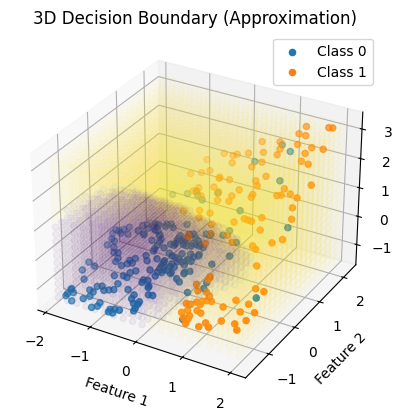

In [ ]:
plot_3d_decision_boundary(X_train, Y_train, model)

In [ ]:
import numpy as np
import plotly.graph_objects as go

def plot_3d_interactive(X_set, y_set, model):
    X_set = np.array(X_set)
    y_set = np.array(y_set).ravel()

    # Create grid
    x_range = np.linspace(X_set[:,0].min(), X_set[:,0].max(), 25)
    y_range = np.linspace(X_set[:,1].min(), X_set[:,1].max(), 25)
    z_range = np.linspace(X_set[:,2].min(), X_set[:,2].max(), 25)

    xx, yy, zz = np.meshgrid(x_range, y_range, z_range)
    grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

    preds = model.predict(grid)

    # Data points
    fig = go.Figure()

    for cls in np.unique(y_set):
        fig.add_trace(go.Scatter3d(
            x=X_set[y_set == cls, 0],
            y=X_set[y_set == cls, 1],
            z=X_set[y_set == cls, 2],
            mode='markers',
            name=f'Class {cls}'
        ))

    # Decision region (light points)
    fig.add_trace(go.Scatter3d(
        x=grid[:,0],
        y=grid[:,1],
        z=grid[:,2],
        mode='markers',
        marker=dict(size=2, color=preds, opacity=0.1),
        name='Decision Region'
    ))

    fig.update_layout(
        title='Interactive 3D Decision Boundary',
        scene=dict(
            xaxis_title='Feature 1',
            yaxis_title='Feature 2',
            zaxis_title='Feature 3'
        )
    )

    fig.show()

In [ ]:
plot_3d_interactive(X_train, Y_train, model)

In [ ]:
import numpy as np
import plotly.graph_objects as go

def plot_glass_clean(X_set, y_set, model):
    X_set = np.array(X_set)
    y_set = np.array(y_set).ravel()

    # Higher resolution grid (important for smoothness)
    res = 50
    x_range = np.linspace(X_set[:,0].min(), X_set[:,0].max(), res)
    y_range = np.linspace(X_set[:,1].min(), X_set[:,1].max(), res)
    z_range = np.linspace(X_set[:,2].min(), X_set[:,2].max(), res)

    xx, yy, zz = np.meshgrid(x_range, y_range, z_range)
    grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

    # Smooth values
    if hasattr(model, "predict_proba"):
        values = model.predict_proba(grid)[:,1]
    else:
        values = model.decision_function(grid)

    fig = go.Figure()

    # 🔷 TRUE decision boundary (single clean surface)
    fig.add_trace(go.Isosurface(
        x=grid[:,0],
        y=grid[:,1],
        z=grid[:,2],
        value=values,
        isomin=0.5,
        isomax=0.5,   # 👈 single thin surface
        surface_count=1,
        opacity=0.18,
        colorscale=[[0, '#AEEFFF'], [1, '#AEEFFF']],  # glass blue
        lighting=dict(
            ambient=0.6,
            diffuse=0.8,
            specular=1.0,
            roughness=0.1,
            fresnel=0.8
        ),
        caps=dict(x_show=False, y_show=False, z_show=False),
        showscale=False
    ))

    # ✨ Clean data points
    colors = ['#00E5FF', '#FF4081']
    for i, cls in enumerate(np.unique(y_set)):
        fig.add_trace(go.Scatter3d(
            x=X_set[y_set == cls, 0],
            y=X_set[y_set == cls, 1],
            z=X_set[y_set == cls, 2],
            mode='markers',
            marker=dict(
                size=5,
                color=colors[i],
                opacity=0.9
            ),
            name=f'Class {cls}'
        ))

    fig.update_layout(
        title="Glass Decision Boundary (Clean)",
        scene=dict(
            bgcolor='black',
            xaxis=dict(showgrid=False),
            yaxis=dict(showgrid=False),
            zaxis=dict(showgrid=False)
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

In [ ]:
# Hyperparameter Tunning : Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.1,1,10,100],
    'gamma' : [1,0.1,0.001,0.01],
    'kernel':["rbf"]
}

In [ ]:
grid = GridSearchCV(estimator=SVC(),param_grid=param_grid,scoring='accuracy',cv=10)

In [ ]:
grid.fit(X_train,Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.001, 0.01],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [ ]:
y_pred = grid.predict(X_test)


In [ ]:
accuracy_score(Y_test,y_pred)

0.9054054054054054

### Processing College.csv Dataset

In [ ]:
df_college = pd.read_csv('/content/College.csv')
display(df_college.head())

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [ ]:
display(df_college.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(16), object(1)
memory usage: 

None

In [ ]:
df_college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [ ]:
df_college['Private']=df_college['Private'].map({'Yes':1,'No':0})

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X_college) and target (Y_college)
Y_college = df_college['Private']
X_college = df_college.drop('Private', axis=1)

In [ ]:
# Split data into training and testing sets
X_train_college, X_test_college, Y_train_college, Y_test_college = train_test_split(X_college, Y_college, test_size=0.2, random_state=0)

In [ ]:
df_college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,1,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,1,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,1,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


### EDA Plotting for `df_college`

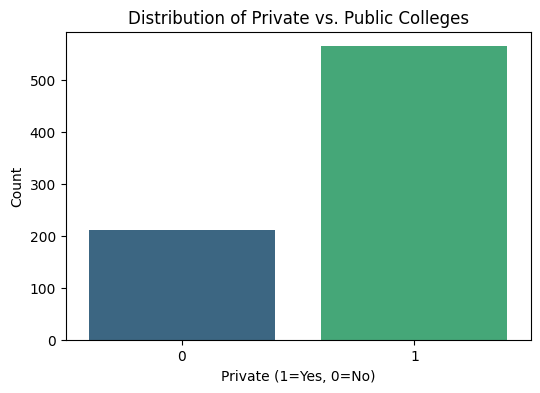

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(x='Private', data=df_college, hue='Private', legend=False, palette='viridis')
plt.title('Distribution of Private vs. Public Colleges')
plt.xlabel('Private (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

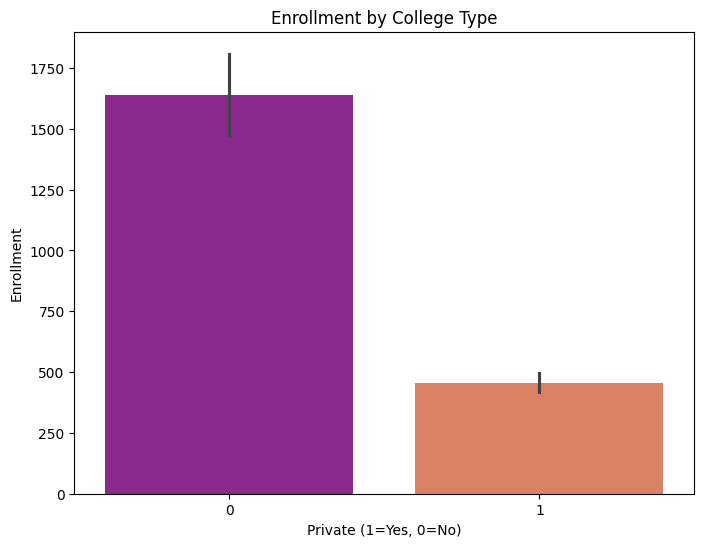

In [ ]:

plt.figure(figsize=(8, 6))
sns.barplot(x='Private', y='Enroll', data=df_college, hue='Private', legend=False, palette='plasma')
plt.title('Enrollment by College Type')
plt.xlabel('Private (1=Yes, 0=No)')
plt.ylabel('Enrollment')
plt.show()

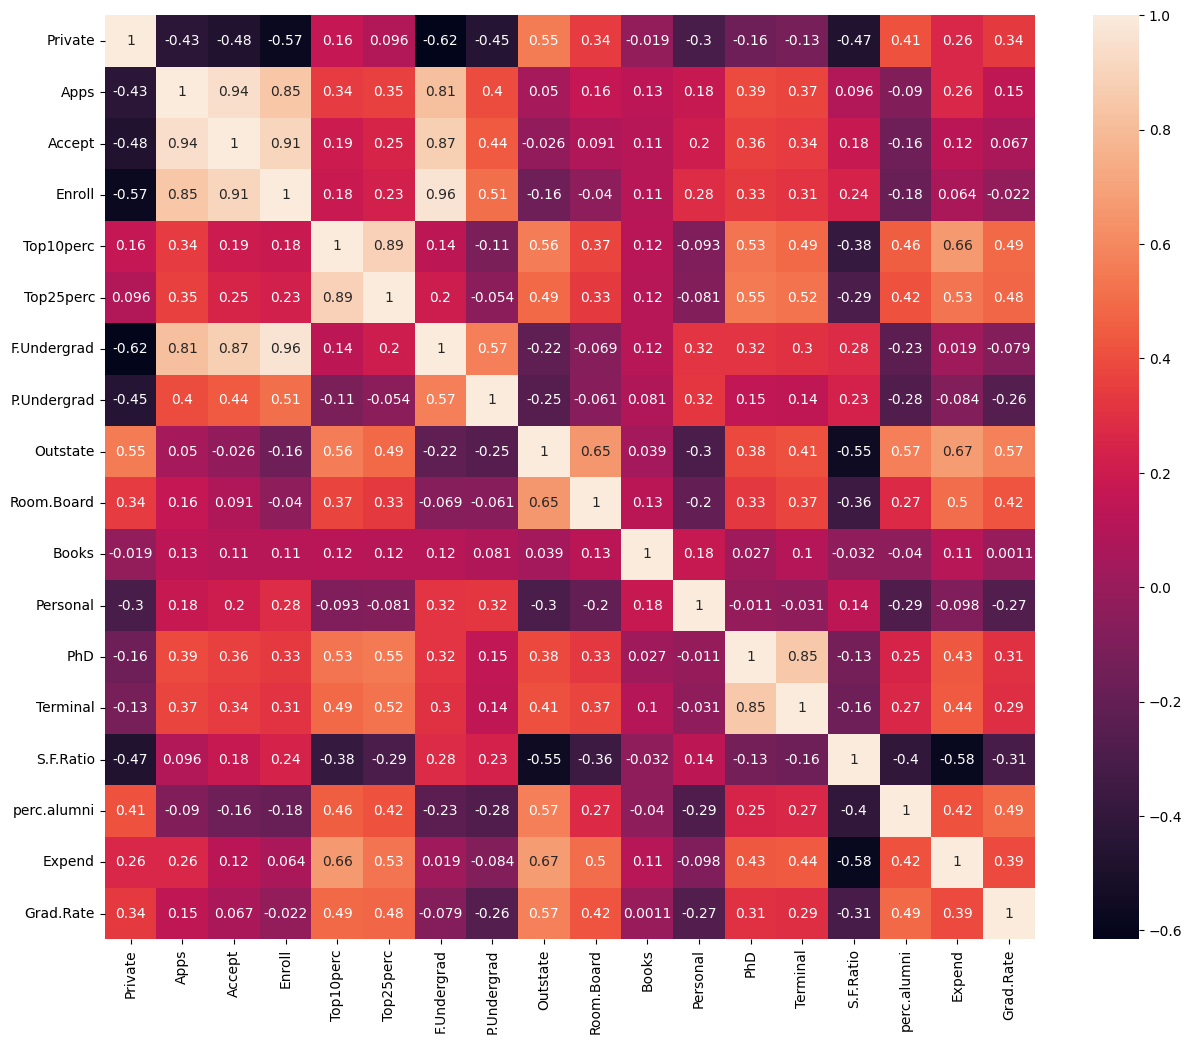

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df_college.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC,LinearSVC
from sklearn.metrics import accuracy_score
sc_college = StandardScaler()

X_train_college_scaled = sc_college.fit_transform(X_train_college)
X_test_college_scaled = sc_college.transform(X_test_college)

In [ ]:

model = SVC(kernel='rbf', random_state=0)
model_l = LinearSVC()
model_l.fit(X_train_college_scaled, Y_train_college)
model.fit(X_train_college_scaled, Y_train_college)

SVC(random_state=0)

In [ ]:

Y_pred_college = model.predict(X_test_college_scaled)
Y_pred_college_l = model_l.predict(X_test_college_scaled)

accuracy_college = accuracy_score(Y_test_college, Y_pred_college)
accuracy_college_l = accuracy_score(Y_test_college, Y_pred_college_l)

print(f"Accuracy with SVC: {accuracy_college}")
print(f"Accuracy with LinearSVC: {accuracy_college_l}")

Accuracy with SVC: 0.9294871794871795
Accuracy with LinearSVC: 0.9230769230769231


### Hyperparameter Tuning for `College.csv` Dataset using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_college = {
    'C' : [0.1,1,10,100],
    'gamma' : [1,0.1,0.001,0.01],
    'kernel':['rbf']
}

grid_college = GridSearchCV(estimator=SVC(), param_grid=param_grid_college, scoring='accuracy', cv=10)

grid_college.fit(X_train_college_scaled, Y_train_college)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.001, 0.01],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [ ]:
Y_pred_college_tuned = grid_college.predict(X_test_college_scaled)
accuracy_college_tuned = accuracy_score(Y_test_college, Y_pred_college_tuned)
print(f"Accuracy after hyperparameter tuning  {accuracy_college_tuned}")
print(grid_college.best_params_)
#best score
print(grid_college.best_score_)

Accuracy after hyperparameter tuning  0.9358974358974359
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.9435483870967742


In [ ]:
Y_pred_college = model.predict(X_test_college_scaled)
accuracy_college = accuracy_score(Y_test_college, Y_pred_college)
print(f"Accuracy with SVC: {accuracy_college}")

Accuracy with SVC: 0.9294871794871795


#Heart

In [ ]:
df = pd.read_csv('/content/heart (1).csv')

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.shape

(303, 14)

In [ ]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

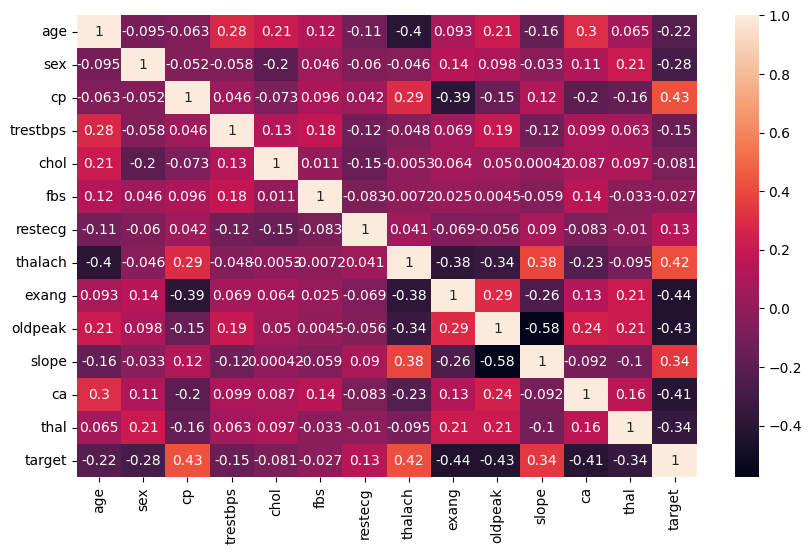

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='age', ylabel='Count'>

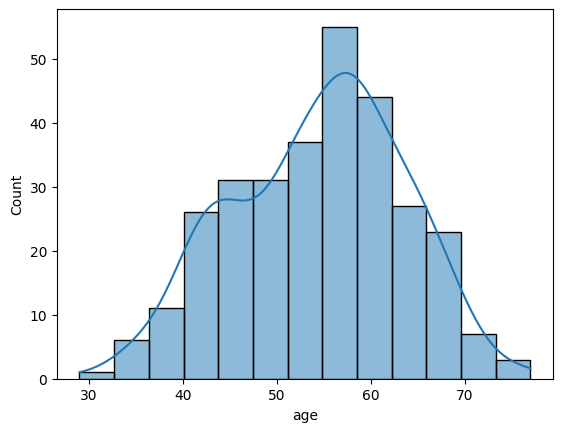

In [ ]:
sns.histplot(df['age'],kde=True)

/tmp/ipykernel_21015/1384229396.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='chol', ylabel='Density'>

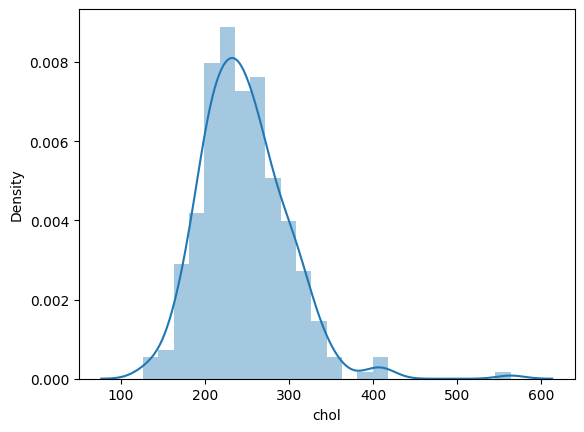

In [ ]:
sns.distplot(df['chol'])

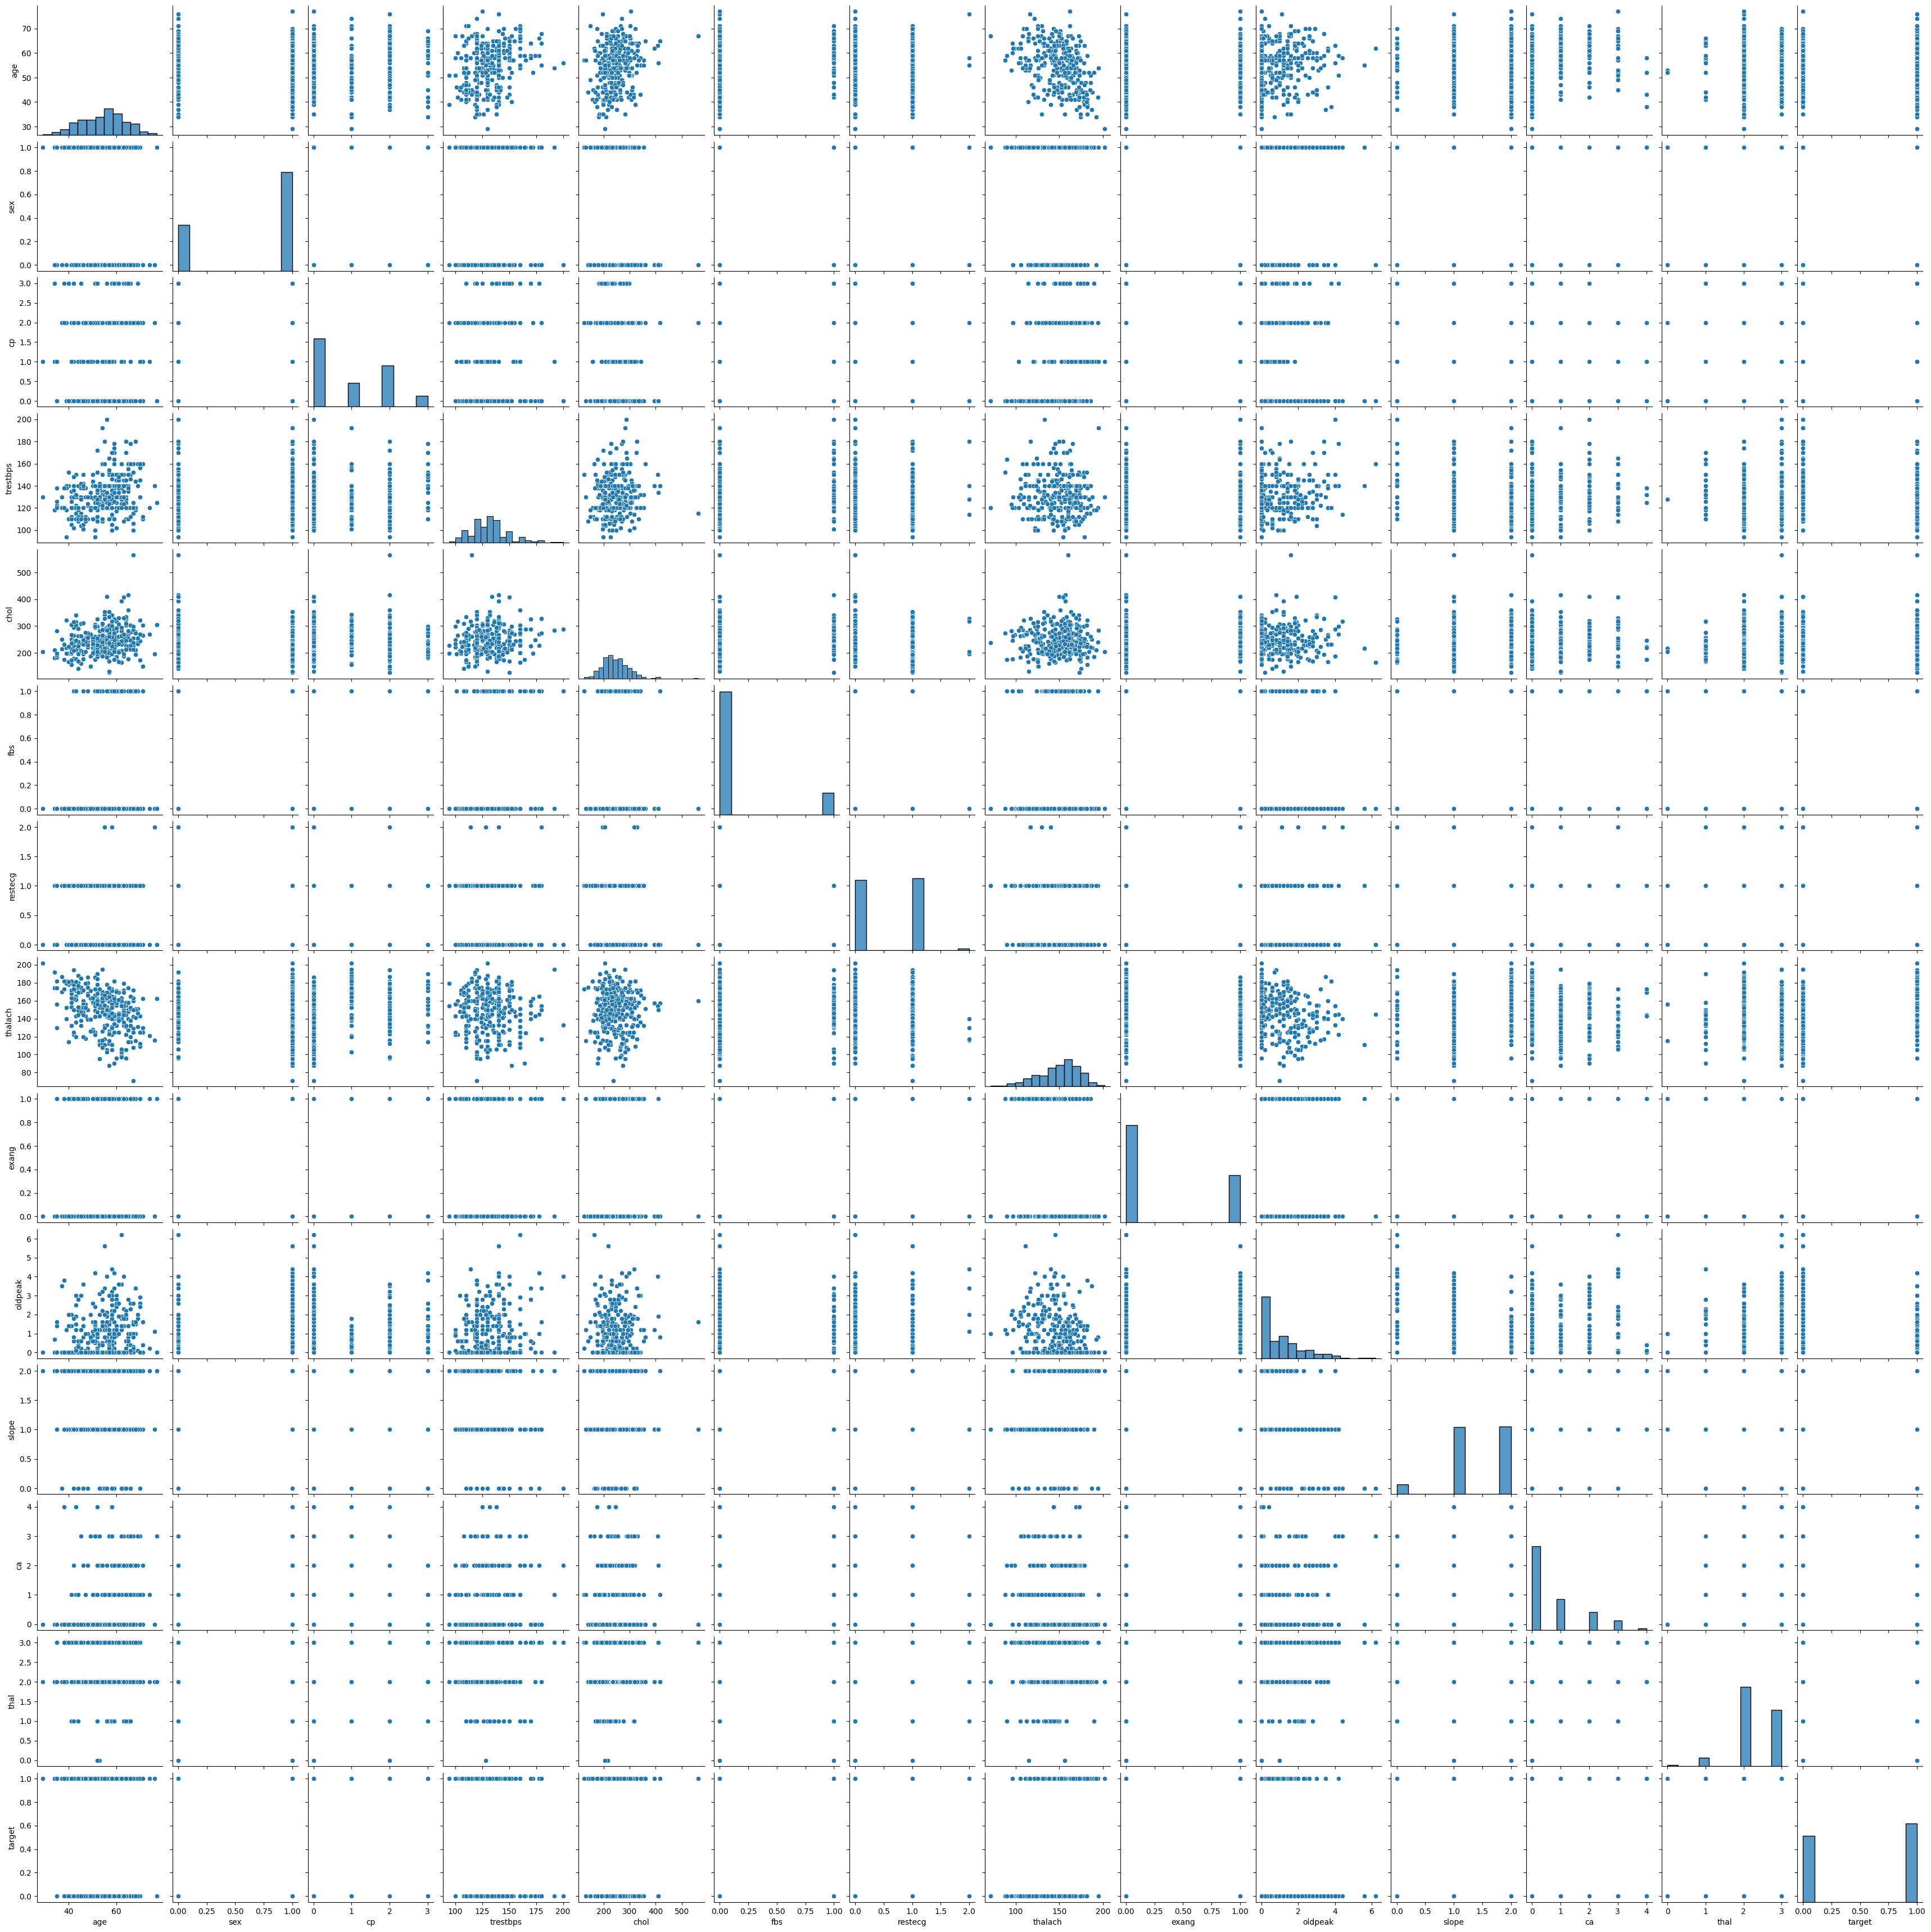

In [ ]:
sns.pairplot(df)

<Axes: xlabel='age', ylabel='chol'>

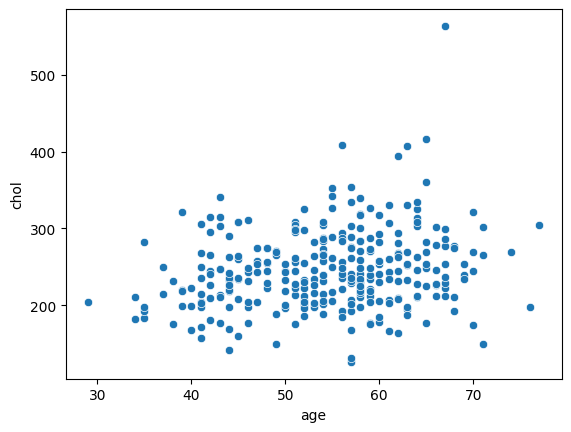

In [ ]:
sns.scatterplot(x=df['age'],y=df['chol'])

In [ ]:
df.nunique()

,0
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [ ]:
df['ageXbp'] = df['age']*df['trestbps']
df['ageXchol']=df['age']*df['chol']
cleaned_df = df.drop(['age','chol','trestbps'],axis=1)

In [ ]:
cleaned_df

,sex,cp,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,ageXbp,ageXchol
0,1,3,1,0,150,0,2.3,0,0,1,1,9135,14679
1,1,2,0,1,187,0,3.5,0,0,2,1,4810,9250
2,0,1,0,0,172,0,1.4,2,0,2,1,5330,8364
3,1,1,0,1,178,0,0.8,2,0,2,1,6720,13216
4,0,0,0,1,163,1,0.6,2,0,2,1,6840,20178
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0,0,0,1,123,1,0.2,1,0,3,0,7980,13737
299,1,3,0,1,132,0,1.2,1,0,3,0,4950,11880
300,1,0,1,1,141,0,3.4,1,2,3,0,9792,13124
301,1,0,0,1,115,1,1.2,1,1,3,0,7410,7467


<Axes: xlabel='sex', ylabel='count'>

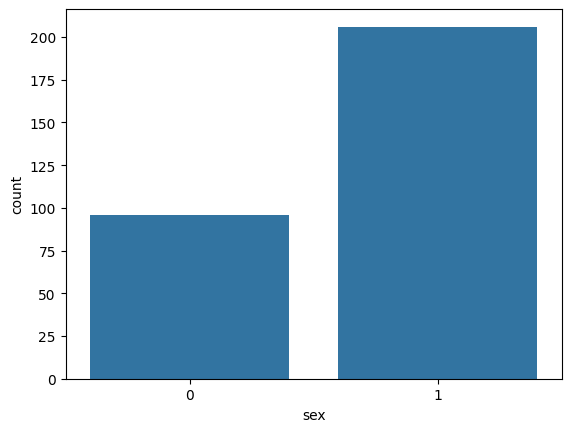

In [ ]:
sns.countplot(x=df['sex'])

In [ ]:
df['sex'].value_counts()

,count
sex,
1,206
0,96


<Axes: xlabel='sex', ylabel='count'>

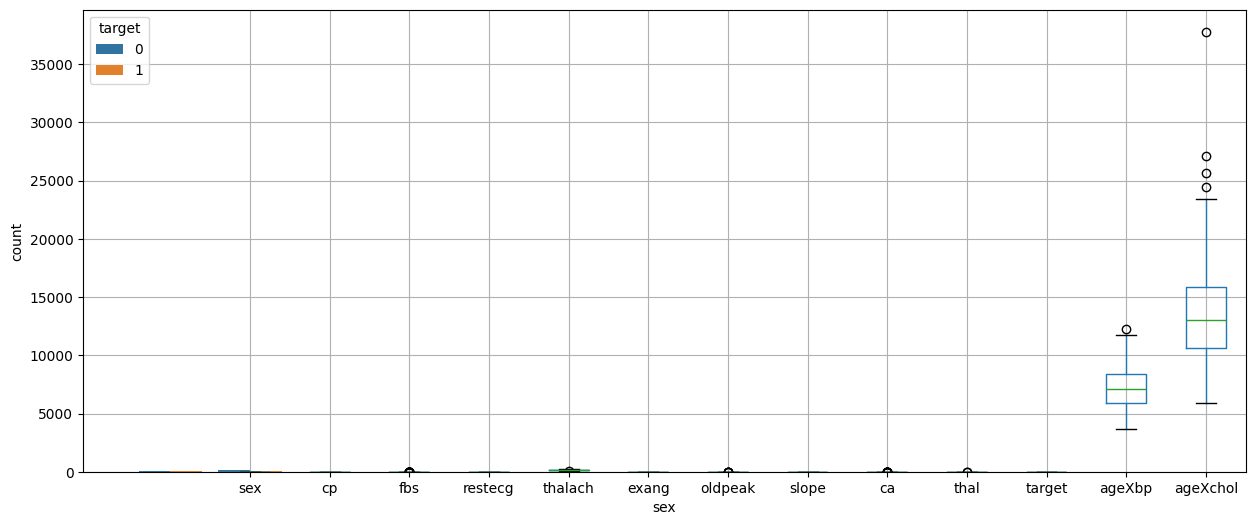

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(x='sex', hue='target', data=df)
cleaned_df.boxplot()

In [ ]:
# iqr

q3 = cleaned_df['ageXbp'].quantile(0.75)
q1 = cleaned_df['ageXbp'].quantile(0.25)
iqr=q3-q1
lr = q1- 1.5*iqr
ur = q3+ 1.5*iqr

cleaned_df['ageXbp'] = cleaned_df['ageXbp'].clip(lower = lr,upper = ur)

In [ ]:

q3 = cleaned_df['ageXchol'].quantile(0.75)
q1 = cleaned_df['ageXchol'].quantile(0.25)
iqr=q3-q1
lr = q1- 1.5*iqr
ur = q3+ 1.5*iqr

cleaned_df['ageXchol'] = cleaned_df['ageXchol'].clip(lower = lr,upper = ur)

<Axes: xlabel='sex', ylabel='count'>

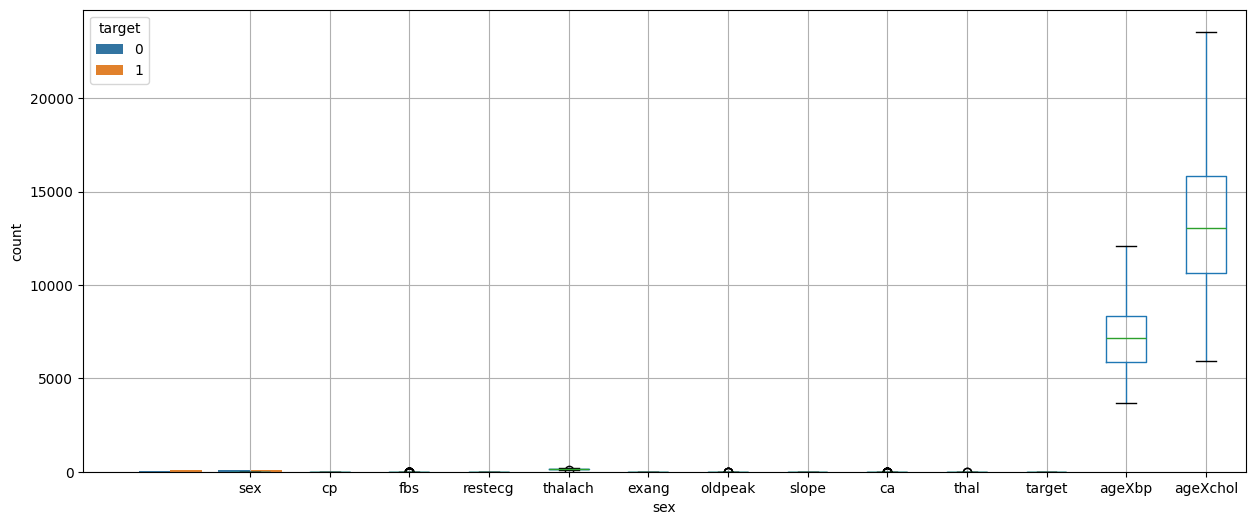

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(x='sex', hue='target', data=df)
cleaned_df.boxplot()

In [ ]:
sc = StandardScaler()
X = cleaned_df.drop('target',axis=1)
Y = cleaned_df['target']
X_scaled = sc.fit_transform(X)


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X_scaled,Y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='rbf',gamma='scale',C=1.0 ,random_state=42)
model.fit(x_train,y_train)

SVC(random_state=42)

In [ ]:
y_pred_svc = model.predict(x_test)

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report


In [ ]:
confusion_matrix(y_test,y_pred_svc)

array([[25,  2],
       [ 3, 31]])

In [ ]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        27
           1       0.94      0.91      0.93        34

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [ ]:
accuracy_svc = accuracy_score(y_test,y_pred_svc)
accuracy_svc

0.9180327868852459

In [ ]:
from sklearn.svm import LinearSVC

model_l = LinearSVC(random_state=42)
model_l.fit(x_train,y_train)

LinearSVC(random_state=42)

In [ ]:
y_pred_l = model_l.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred_l)

array([[23,  4],
       [ 3, 31]])

In [ ]:
print(classification_report(y_test,y_pred_l))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87        27
           1       0.89      0.91      0.90        34

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.88        61



In [ ]:
accuracy_l = accuracy_score(y_test,y_pred_l)
accuracy_l

0.8852459016393442

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.1,1,10],
    'gamma' : [1,0.1,0.01,0.001], # Removed 0.0 and added 0.01 for better tuning range
    'kernel':['rbf']
}

grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, scoring='accuracy', cv=10)

grid.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [ ]:
y_pred_grid = grid.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred_grid)

array([[21,  6],
       [ 3, 31]])

In [ ]:
print(classification_report(y_test,y_pred_grid))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82        27
           1       0.84      0.91      0.87        34

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.85      0.85      0.85        61



In [ ]:
accuracy_grid = accuracy_score(y_test,y_pred_grid)
accuracy_grid

0.8524590163934426

In [ ]:
grid.best_score_

np.float64(0.8218333333333334)